### Explorando o Dataset

In [7]:
import pandas as pd
from data.data_loader import DAPT2020
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
dapt = DAPT2020("data/dapt2020.csv", "Stage", 1, remove_outliers=False)
df = pd.DataFrame(dapt.X_set, columns=dapt.features_names)
df.head()

Dataset loaded with 86688 samples and 79 features.
Number of samples of class benign: 63711
Number of samples of class reconnaissance: 11909
Number of samples of class establish foothold: 8604
Number of samples of class lateral movement: 2451
Number of samples of class data exfiltration: 15
Train size: 60681, Test size: 26007


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.999328,0.668511,-0.294118,-0.928197,-0.999951,-0.999923,-0.999994,-0.999991,-0.994041,-1.000000,...,-0.999956,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-0.997923,-0.997952,1.000000,0.994582,-0.999606,-1.000000,-0.999796,-0.999994,-0.990813,-0.950276,...,-0.999606,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,0.414250,-0.998380,1.000000,-0.999635,-0.999996,-0.999992,-1.000000,-0.999995,-0.998603,-0.992231,...,-0.999996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,-1.000000,-1.000000,-1.000000,0.999984,-0.998901,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,0.187537,-0.998380,1.000000,-0.999738,-0.999996,-0.999992,-1.000000,-0.999990,-0.998355,-0.990849,...,-0.999996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


### Features tunning

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(dapt.X_set, dapt.Y_set)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


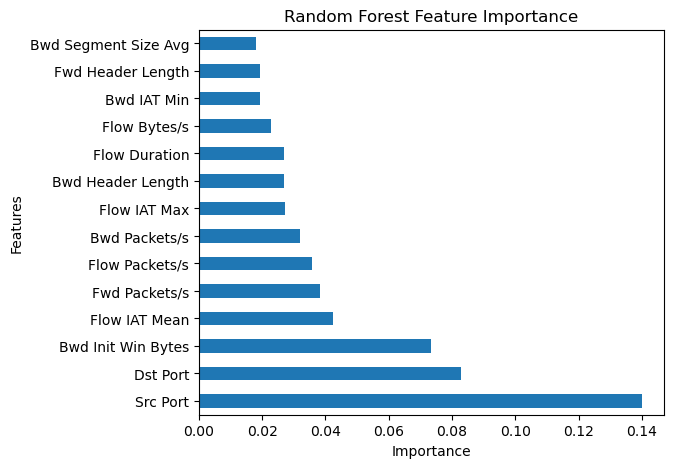

In [9]:
importance_by_feature = pd.Series(rf.feature_importances_, index=dapt.features_names)
importance_by_feature.sort_values(ascending=False, inplace=True)

# 81 features, so the average importance is 1/81 = 0.0123
# So features with an importance greater than 0.02 are considered important

importance_by_feature = importance_by_feature[importance_by_feature > 0.018] #using 0.15 for the sake of visualization
importance_by_feature.plot(kind="barh", figsize=(6, 5))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [9]:
importance_by_feature.to_dict().keys()

dict_keys(['Src Port', 'Dst Port', 'Bwd Init Win Bytes', 'Flow IAT Mean', 'Fwd Packets/s', 'Flow Packets/s', 'Bwd Packets/s', 'Flow IAT Max', 'Bwd Header Length', 'Flow Duration', 'Flow Bytes/s', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Segment Size Avg'])

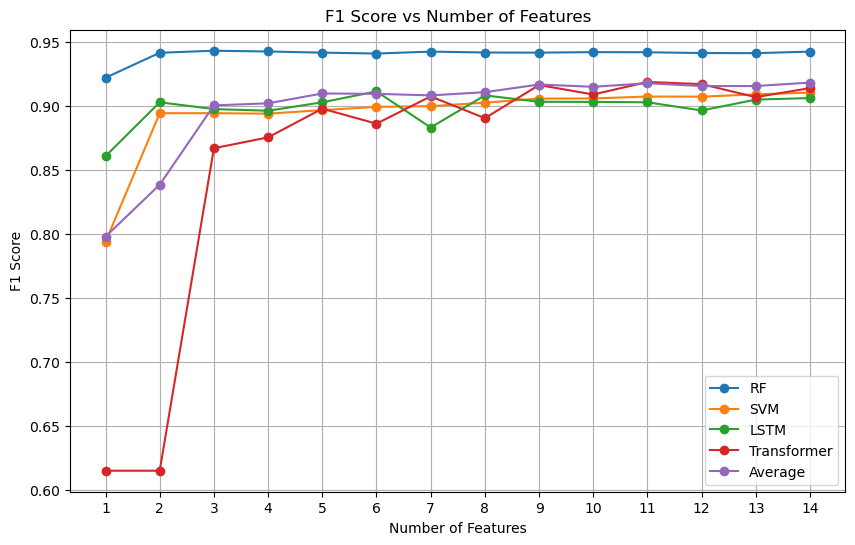

In [10]:
df = pd.read_csv("experiments/features_tuning_results.csv")

# Plota os resultados
plt.figure(figsize=(10, 6))
num_features = df['num_features']
plt.plot(num_features, df['RF'], label='RF', marker='o')
plt.plot(num_features, df['SVM'], label='SVM', marker='o')
plt.plot(num_features, df['LSTM'], label='LSTM', marker='o')
plt.plot(num_features, df['Transformer'], label='Transformer', marker='o')
plt.plot(num_features, df['Average'], label='Average', marker='o')
plt.title('F1 Score vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('F1 Score')
plt.xticks(num_features)
plt.legend()
plt.grid()
plt.show()

### Evaluation Plots

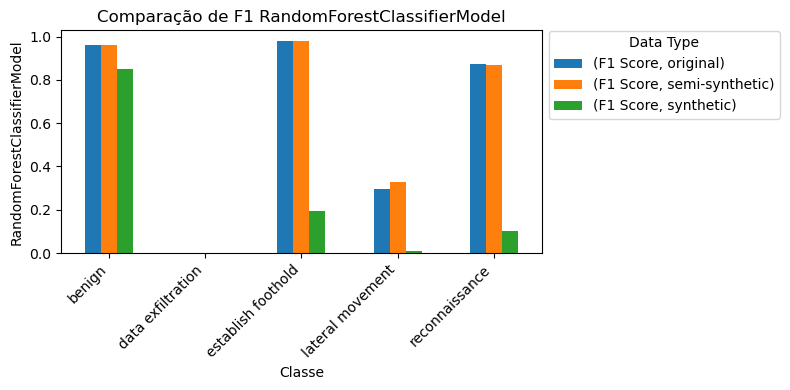

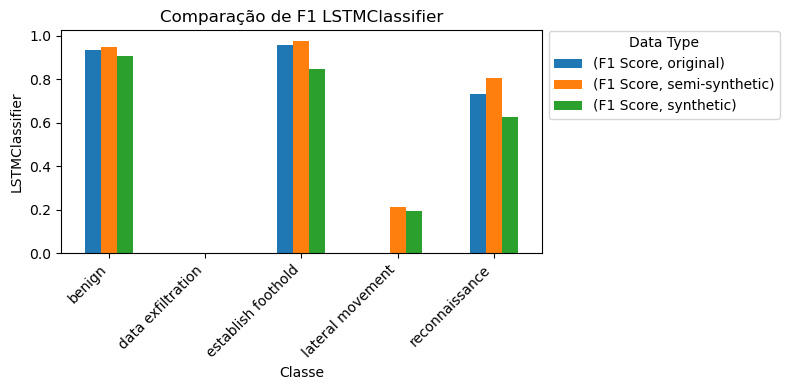

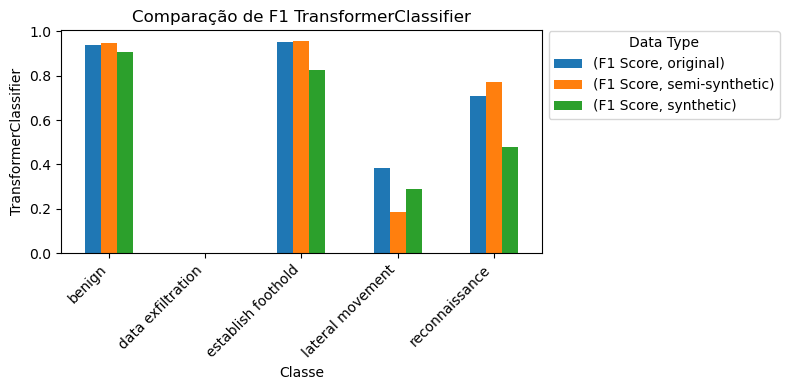

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_class_performance(csv_path: str):
    # Lê o CSV
    df = pd.read_csv(csv_path)
    
    # Remove linhas agregadas "Overall" (opcional)
    df = df[df["Class Name"] != "Overall"]

    # Converte colunas de métricas para numéricas (evita problemas com '-')
    classifiers = df['Classifier'].unique().tolist()
    df['F1 Score'] = pd.to_numeric(df['F1 Score'], errors="coerce")
    df = df.drop('Recall', axis=1)
    df = df.drop('Precision', axis=1)
    df = df.drop('Support', axis=1)

    # Itera pelas métricas e cria gráficos
    for metric in classifiers:
        plt.figure(figsize=(8, 4))
        
        pivot_df = df[df['Classifier'] == metric]  
        pivot_df = pivot_df.pivot(index="Class Name", columns="Data Type")
        
        # Plot de barras lado a lado
        pivot_df.plot(kind="bar", ax=plt.gca())
        
        plt.title(f"Comparação de F1 {metric}")
        plt.ylabel(metric)
        plt.xlabel("Classe")
        plt.xticks(rotation=45, ha="right")
        plt.legend(title="Data Type", loc='center left', bbox_to_anchor=(1.0, 0.8))
        plt.tight_layout()
        plt.show()

plot_class_performance("experiments/results/TTS-CGAN_results_15_50_47.csv")

### DTW

c:\Users\Alfredo\source\repos\cyberdata-improvement-tts-cgan\data\DataLoader.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_train['Timestamp'] = pd.to_datetime(data_train['Timestamp'], errors='coerce')


Foram removidos 5382 outliers


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


X train shape is (1897, 30, 6)
Y train shape is (1897,)
Quantidade de amostras da classe benign: 1657
Quantidade de amostras da classe reconnaissance: 505
Quantidade de amostras da classe establish foothold: 365
Quantidade de amostras da classe lateral movement: 174
Quantidade de amostras da classe data exfiltration: 10


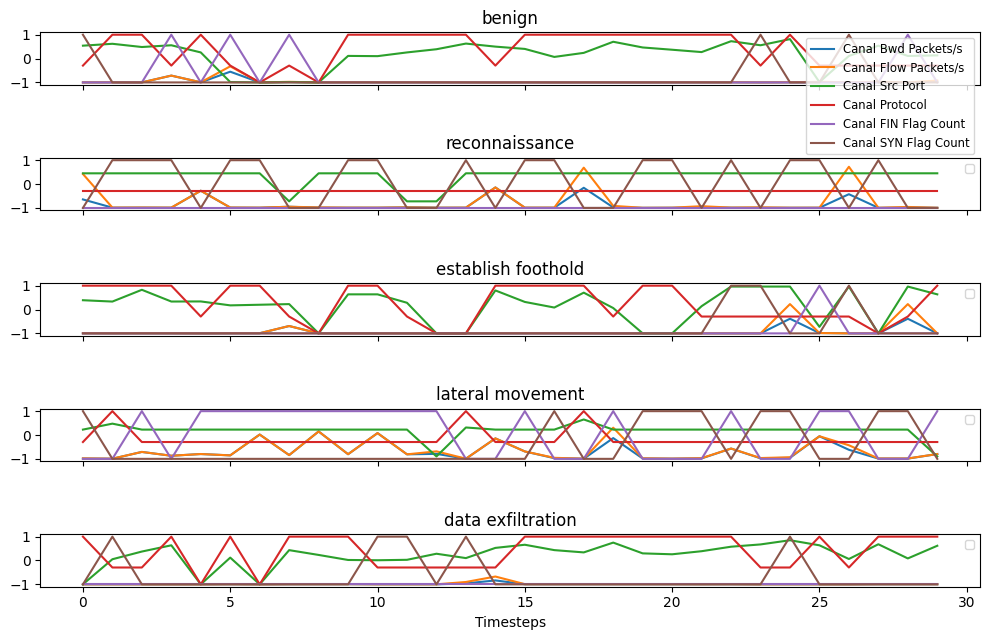

In [ ]:
from data.DataLoader import DAPT2020
import numpy as np
# Carregar e pré-processar os dados
features_to_train = ['Bwd Packets/s', 'Flow Packets/s', 'Src Port', 'Protocol', 'FIN Flag Count', 'SYN Flag Count', 'Timestamp']
label_column = 'Stage'
seq_len = 30
filename = "data/output.csv"

#ja embaralhado por padrao
data_set = DAPT2020(filename, features_to_train, label_column, seq_len, expand=False)
X_train = data_set.X_set
Y_train = data_set.Y_set #labels
class_names = data_set.classes
# cada sequencia possui 6 canais e 30 timesteps, plotar uma amostra de cada labels
# Obter rótulos únicos
labels = np.unique(Y_train)
# Índices do primeiro exemplo de cada label
examples_idx = [np.where(Y_train == label)[0][0] for label in labels]

# Parâmetros
_, T, C = X_train.shape
colors = plt.cm.tab10.colors  # até 10 cores distintas

# Criar subplots
fig, axs = plt.subplots(len(labels), 1, figsize=(10, 1.3*len(labels)), sharex=True)

for i, (label, idx) in enumerate(zip(labels, examples_idx)):
    axs[i].set_title(f"{class_names[label]}")
    for c in range(C):
        if label == 0:
            axs[i].plot(X_train[idx, :, c], label=f"Canal {features_to_train[c]}", color=colors[c % len(colors)])
        else:
            axs[i].plot(X_train[idx, :, c], color=colors[c % len(colors)])
    axs[i].legend(loc='upper right', fontsize='small')

plt.xlabel("Timesteps")
plt.tight_layout()
plt.show()


## Gerando dados sintéticos
Isso aqui n deve ta funcionando eu acho

#### PCA e T-SNE

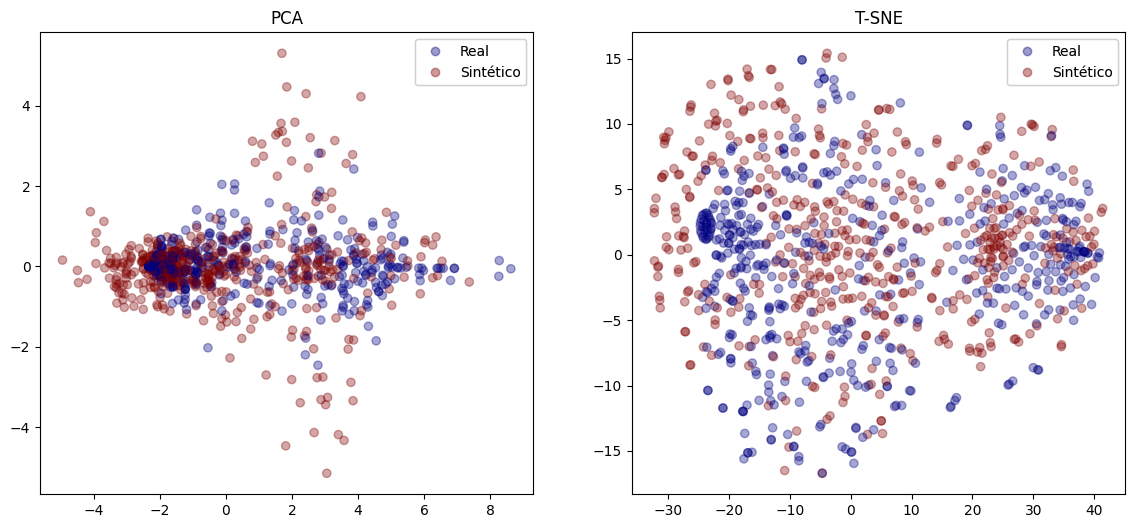

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_series_comparison(series1, series2, method='both'):
    """
    Plota a comparação entre duas séries temporais usando PCA e T-SNE.

    Args:
        series1 (np.ndarray): Primeira série temporal (n amostras, d dimensões).
        series2 (np.ndarray): Segunda série temporal (n amostras, d dimensões).
        method (str): 'pca' para apenas PCA, 'tsne' para apenas T-SNE, ou 'both' para ambos.

    Returns:
        None
    """
    assert series1.shape == series2.shape, "As séries devem ter o mesmo formato."

    #pega apenas mil amostras, aleatoriamente
    n_samples = 500
    indices = np.random.choice(series1.shape[0], n_samples, replace=False)
    series1 = series1[indices]
    series2 = series2[indices]

    # Intercala os dados
    interleaved_data = np.empty((series1.shape[0] + series2.shape[0], series1.shape[1]))
    interleaved_labels = np.empty(series1.shape[0] + series2.shape[0], dtype=int)

    interleaved_data[0::2] = series1
    interleaved_data[1::2] = series2
    interleaved_labels[0::2] = 0  # reais
    interleaved_labels[1::2] = 1  # sintéticos

    # Criando os subplots dinamicamente
    if method == 'both':
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        methods = ['PCA', 'T-SNE']
    else:
        fig, axes = plt.subplots(1, 1, figsize=(7, 6))
        methods = [method.upper()]
        axes = [axes]

    for ax, m in zip(axes, methods):
        if m == 'PCA':
            reducer = PCA(n_components=2)
        elif m == 'T-SNE':
            reducer = TSNE(n_components=2, perplexity=30, random_state=42)
        else:
            raise ValueError("Método inválido. Escolha 'pca', 'tsne' ou 'both'.")

        reduced = reducer.fit_transform(interleaved_data)
        scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=interleaved_labels, cmap='jet', alpha=0.35)
        legend = ax.legend(*scatter.legend_elements())
        ax.add_artist(legend)
        legend.get_texts()[0].set_text("Real")
        legend.get_texts()[1].set_text("Sintético")
        #legenda para os dados artificiais e os reais

        ax.set_title(f"{m}")
    
    plt.show()

plot_series_comparison(x_train[:, :, 0, :].reshape(-1, seq_len), x_synt[:, :, 0, :].reshape(-1, seq_len), method='both')
